In [37]:
# # This installs the specific GNN libraries we need for your thesis
# !pip install torch torchvision torchaudio
# !pip install torch-geometric
# !pip install matplotlib pandas
# print("Installation Successful!")

In [38]:
# # 1. Force a clean, simple install
# !pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cpu

# # 2. Use the 'pure python' version of torch-geometric (avoids the DLL error)
# !pip install torch-geometric

In [39]:
# Main Toolkits

import torch
import torch_geometric
from torch_geometric.datasets import QM9
print(f"PyTorch version: {torch.__version__}")
print(f"PyG version: {torch_geometric.__version__}")


# Dataset containing roughly 130,000 small molecules.
dataset = QM9(root='data/QM9')
print(f"Dataset loaded! Total molecules: {len(dataset)}")

sample = dataset[0]  #This picks the very first molecule from the list (Methane).
print(f"Sample molecule atoms: {sample.z}")  # gives the atomic numbers of the atoms in the molecule.
print(f"Sample molecule positions: \n{sample.pos}") # gives the 3D coordinates of each atom in the molecule.

PyTorch version: 2.1.2+cpu
PyG version: 2.7.0
Dataset loaded! Total molecules: 130831
Sample molecule atoms: tensor([6, 1, 1, 1, 1])
Sample molecule positions: 
tensor([[-1.2700e-02,  1.0858e+00,  8.0000e-03],
        [ 2.2000e-03, -6.0000e-03,  2.0000e-03],
        [ 1.0117e+00,  1.4638e+00,  3.0000e-04],
        [-5.4080e-01,  1.4475e+00, -8.7660e-01],
        [-5.2380e-01,  1.4379e+00,  9.0640e-01]])


In [40]:
# !pip install matplotlib

In [41]:
# import sys
# import subprocess

# subprocess.check_call([sys.executable, "-m", "pip", "install", "numpy<2", "matplotlib"])
# print("NumPy and Matplotlib installed successfully!")

In [42]:
# import sys
# !{sys.executable} -m pip install "numpy<2" matplotlib

In [43]:
# import torch
# import numpy
# from torch_geometric.datasets import QM9
# import matplotlib.pyplot as plt
# from mpl_toolkits.mplot3d import Axes3D

# # 1. Load the data again into the current memory
# dataset = QM9(root='data/QM9')

# # 2. Get the methane molecule (Carbon + 4 Hydrogens)
# sample = dataset[0] 
# pos = sample.pos.numpy()

# # 3. Create the 3D plot
# fig = plt.figure(figsize=(8, 8))
# ax = fig.add_subplot(111, projection='3d')

# # Color atoms by their atomic number (z)
# # 6 is Carbon (Red-ish), 1 is Hydrogen (Blue-ish)
# scatter = ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=500, c=sample.z.numpy(), cmap='coolwarm')

# ax.set_title("Methane (CH4) 3D Molecular Manifold")
# ax.set_xlabel("X-axis")
# ax.set_ylabel("Y-axis")
# ax.set_zlabel("Z-axis")
# plt.show()

In [44]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


# sample = dataset[0] 
# pos = sample.pos.numpy()

# fig = plt.figure(figsize=(8, 8))
# ax = fig.add_subplot(111, projection='3d')

# # Color atoms by their type (Carbon=6, Hydrogen=1)
# ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=500, c=sample.z.numpy(), cmap='coolwarm')

# ax.set_title("Methane (CH4) 3D Structure")
# plt.show()

In [45]:
# %matplotlib qt

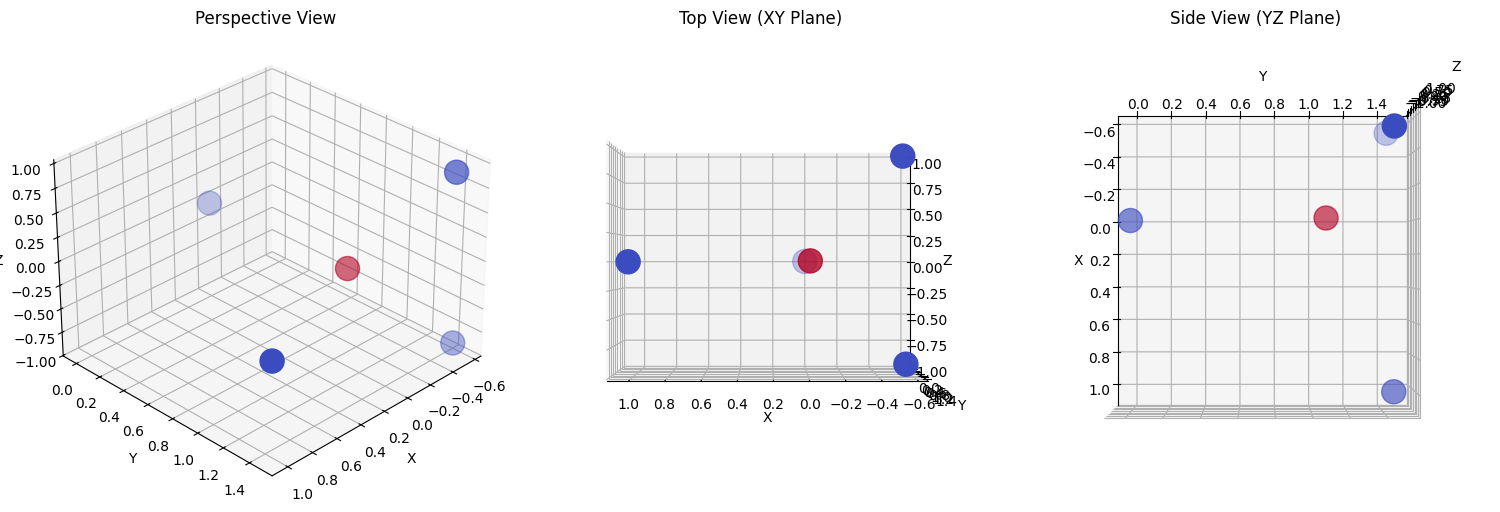

In [46]:
fig = plt.figure(figsize=(15, 5))

# View angles to demonstrate SO(3) rotation
views = [(30, 45), (0, 90), (90, 0)] # (elev, azim) pairs for perspective, top, and side views
titles = ["Perspective View", "Top View (XY Plane)", "Side View (YZ Plane)"]

for i, (elev, azim) in enumerate(views):
    ax = fig.add_subplot(1, 3, i+1, projection='3d')
    ax.scatter(pos[:, 0], pos[:, 1], pos[:, 2], s=300, c=sample.z.numpy(), cmap='coolwarm') #Drawing the atoms as points in a 3D graph.
    ax.view_init(elev=elev, azim=azim) # Moving the camera to those angles.
    ax.set_title(titles[i])
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")

plt.tight_layout()
plt.show()

In [47]:
import networkx as nx
from torch_geometric.utils import to_networkx
import torch

def add_graph_coloring_features(data):
    """
    Computes a greedy graph coloring and adds it as a feature to the molecule.
    """
    # 1. Convert PyTorch Geometric data to NetworkX graph
    G = to_networkx(data, to_undirected=True)
    
    # 2. Perform Greedy Coloring
    coloring_dict = nx.coloring.greedy_color(G, strategy="largest_first") # Ensure no two connected atoms have the same color index.
    
    # 3. Map colors back to node order
    colors = [coloring_dict[i] for i in range(data.num_nodes)]
    
    # 4. Convert to a tensor and add it to the data object
    color_tensor = torch.tensor(colors, dtype=torch.float).view(-1, 1) # We reshape it to [num_nodes, 1] to be used as a feature
    
    # Combine with existing features if any or create new ones
    # For QM9, data.z is the atomic number. We add the color next to it.
    data.x = torch.cat([data.z.view(-1, 1).float(), color_tensor], dim=-1)
    
    return data

# Test on our sample molecule from the notebook
sample_molecule = dataset[0]
sample_with_colors = add_graph_coloring_features(sample_molecule)

print(f"Original features (Atomic Numbers): \n{sample_molecule.z}")
print(f"New features (Atomic Number + Color): \n{sample_with_colors.x}")


Original features (Atomic Numbers): 
tensor([6, 1, 1, 1, 1])
New features (Atomic Number + Color): 
tensor([[6., 0.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])


In [48]:
import numpy as np

# A simple 90-degree rotation matrix around the Z-axis (An element of the Lie Group SO(3))
theta = np.radians(90)
rotation_matrix = torch.tensor([
    [np.cos(theta), -np.sin(theta), 0],
    [np.sin(theta),  np.cos(theta), 0],
    [0,              0,             1]
], dtype=torch.float)

# Apply rotation to the atom positions
original_pos = dataset[0].pos
rotated_pos = torch.matmul(original_pos, rotation_matrix)

print("Original Positions (First 2 atoms):\n", original_pos[:2])
print("\nRotated Positions (First 2 atoms):\n", rotated_pos[:2])

Original Positions (First 2 atoms):
 tensor([[-0.0127,  1.0858,  0.0080],
        [ 0.0022, -0.0060,  0.0020]])

Rotated Positions (First 2 atoms):
 tensor([[ 1.0858,  0.0127,  0.0080],
        [-0.0060, -0.0022,  0.0020]])


In [49]:
# # import torch
# # import torch.nn.functional as F
# from torch_geometric.nn import GCNConv, global_mean_pool

# class LieColorGNN(torch.nn.Module):
#     def __init__(self, hidden_channels):
#         super(LieColorGNN, self).__init__()
#         torch.manual_seed(42)
#         # Input features = 2 (Atomic Number + Color)
#         self.conv1 = GCNConv(2, hidden_channels)
#         self.conv2 = GCNConv(hidden_channels, hidden_channels)
#         self.conv3 = GCNConv(hidden_channels, hidden_channels)
#         # Output layer for molecular property prediction (Regression)
#         self.lin = torch.nn.Linear(hidden_channels, 1)

#     def forward(self, x, edge_index, batch):
#         # 1. First Message Passing layer
#         x = self.conv1(x, edge_index)
#         x = x.relu()
#         # 2. Second layer
#         x = self.conv2(x, edge_index)
#         x = x.relu()
#         # 3. Third layer
#         x = self.conv3(x, edge_index)

#         # 4. Readout layer: Pooling node features into a single graph embedding
#         # This is where 'Invariance' is finalized
#         x = global_mean_pool(x, batch) 

#         # 5. Final Prediction
#         x = F.dropout(x, p=0.5, training=self.training)
#         x = self.lin(x)
#         return x

# model = LieColorGNN(hidden_channels=64)
# print(model)

In [50]:
# First molecule in our dataset
sample = dataset[0]

# edge_index tells which atoms are connected by bonds
print("The 'Bonds' (Connections) in this molecule are:")
print(sample.edge_index)

# This counts how many connections each atom has
from torch_geometric.utils import degree
node_connections = degree(sample.edge_index[0])
print("\nNumber of connections for each atom:")
print(node_connections)

The 'Bonds' (Connections) in this molecule are:
tensor([[0, 0, 0, 0, 1, 2, 3, 4],
        [1, 2, 3, 4, 0, 0, 0, 0]])

Number of connections for each atom:
tensor([4., 1., 1., 1., 1.])
